# Fit model parameters to data

Estimates the rate constants of `mm.bngl` from the data in `mm.csv` using [pyPESTO](https://github.com/icb-dcm/pypesto).

Simulations use [bngsim](https://bngsim.readthedocs.io), which loads BioNetGen models directly and runs ODE and stochastic (SSA) simulations in-process. `bngsim.Model.from_bngl` generates the reaction network with BioNetGen and loads it; the `simulate` actions at the end of the `.bngl` file are not run.

Two things to remember:
- Parameters are changed on the **model** (`model.set_param`), and simulations are run by a **simulator** (`sim.run`).
- A run starts from the model's *current* state. Call `model.reset()` before each run to start from the initial conditions (this also applies new initial-condition parameters such as `L0`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bngsim

# Load model from BNGL
model_name = 'mm'
model = bngsim.Model.from_bngl('../models/' + model_name + '.bngl')
sim = bngsim.Simulator(model, method="ode")
onames = model.observable_names
pnames = model.primary_param_names
pvals = np.array([model.get_param(p) for p in pnames])
print(dict(zip(pnames, pvals)))

{'k1': 1e-05, 'k2': 0.1, 'k3': 0.1}


## Read data from file

In [2]:
fitdata = pd.read_csv(model_name + '.csv', header=0, delimiter=",")  # reads in data file
tdat = fitdata['Time'].values
odat = fitdata[onames[-1]].values  # ensure compatibility of data and last observable

## Function to run simulation of model with input parameter vector

In [3]:
def run_model(sim, times, params):
    # Set model parameter values
    model.set_params(dict(zip(pnames, params)))
    # Reset species to their initial values before simulating
    model.reset()
    return sim.run(sample_times=times)

## Set up cost function

In [4]:
def cost(pvals):
    res = run_model(sim, tdat, pvals)
    y = res.observables[onames[-1]]
    sigma = odat.copy()
    sigma[0] = 1.0
    nll = np.sum(((y - odat) / sigma)**2)  # chi^2
    return nll  # negative log likelihood - smaller is better

## Compare model and data

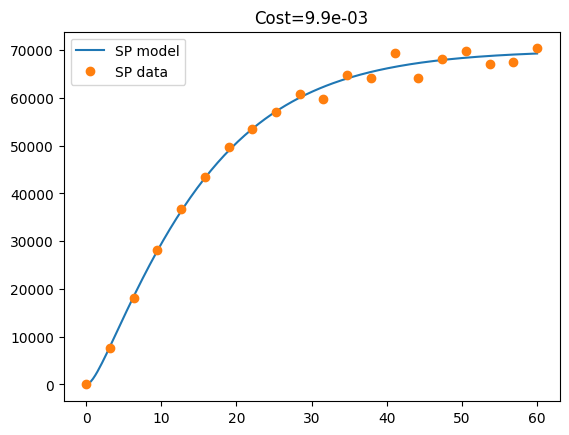

In [5]:
tsim = np.linspace(tdat[0], tdat[-1], 200)

def plot_comparison(p):
    o = onames[-1]
    res = run_model(sim, tsim, p)
    plt.plot(tsim, res.observables[o], label=o + ' model')
    plt.plot(fitdata['Time'].values, fitdata[o].values, 'o', label=o + ' data')
    plt.title(f'Cost={cost(p):0.1e}')
    _ = plt.legend()

plot_comparison(pvals)

## Use the pyPESTO package to perform parameter estimation

In [6]:
import pypesto
import pypesto.optimize as optimize
import pypesto.visualize as visualize

# log scale parameters to improve optimization
cost_pp = lambda p: cost(10**p)
# Set upper and lower bounds on parameters
ub = np.log10(pvals) + 2
lb = np.log10(pvals) - 2

# create pypesto problem
model_loss = pypesto.Objective(fun=cost_pp)
problem = pypesto.Problem(objective=model_loss, x_names=pnames, lb=lb, ub=ub)

### Perform optimization

  0%|          | 0/100 [00:00<?, ?it/s]

  5%|▌         | 5/100 [00:00<00:02, 44.74it/s]

 10%|█         | 10/100 [00:00<00:02, 35.26it/s]

 14%|█▍        | 14/100 [00:00<00:03, 21.55it/s]

 17%|█▋        | 17/100 [00:00<00:03, 22.35it/s]

...

 88%|████████▊ | 88/100 [00:02<00:00, 26.92it/s]

 92%|█████████▏| 92/100 [00:03<00:00, 28.29it/s]

 95%|█████████▌| 95/100 [00:03<00:00, 24.13it/s]

 99%|█████████▉| 99/100 [00:03<00:00, 25.12it/s]

100%|██████████| 100/100 [00:03<00:00, 29.18it/s]

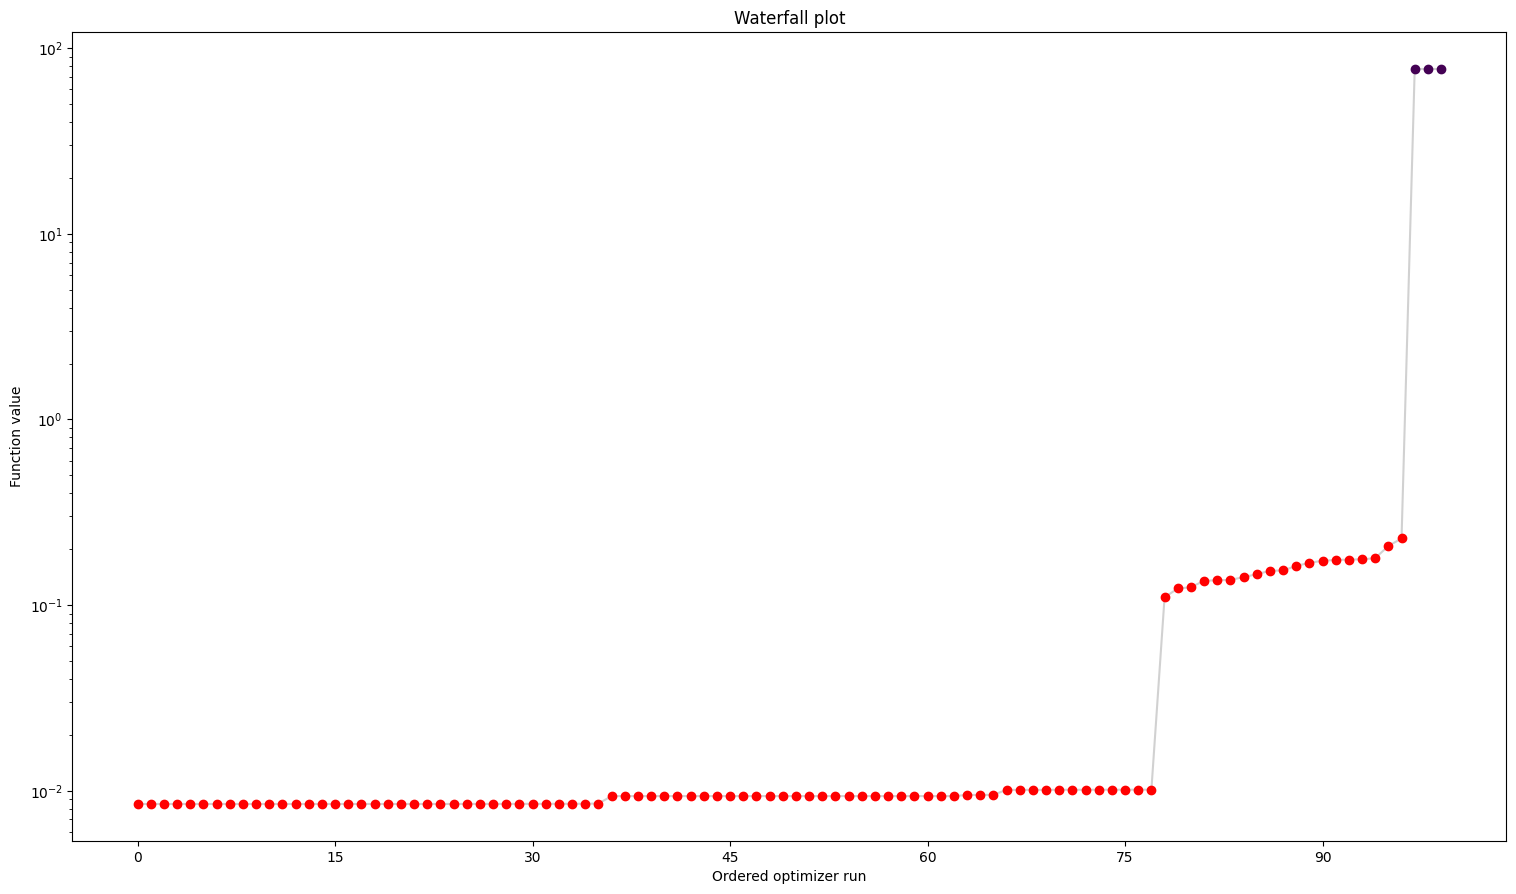

In [7]:
# choose optimizer
optimizer = optimize.ScipyOptimizer(method='L-BFGS-B')

# do the optimization
result = optimize.minimize(
    problem=problem, optimizer=optimizer, n_starts=100
)

_ = visualize.waterfall(result, offset_y=0, scale_y='log10')

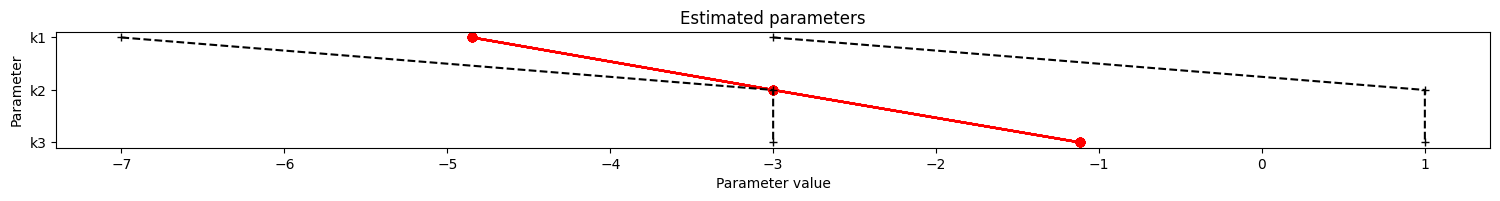

In [8]:
_ = visualize.parameters(result, start_indices=15)

fitted:  {'k1': 1.4171059184915343e-05, 'k2': 0.001, 'k3': 0.0768505153487655}
true:    {'k1': 1e-05, 'k2': 0.1, 'k3': 0.1}


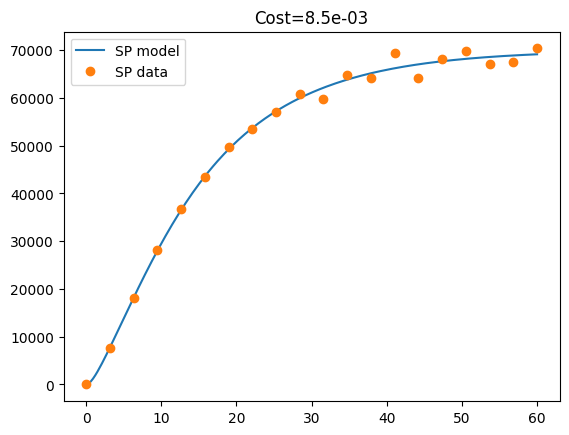

In [9]:
popt = 10**result.optimize_result.list[0]['x']
plot_comparison(popt)
print("fitted: ", dict(zip(pnames, popt)))
print("true:   ", dict(zip(pnames, pvals)))

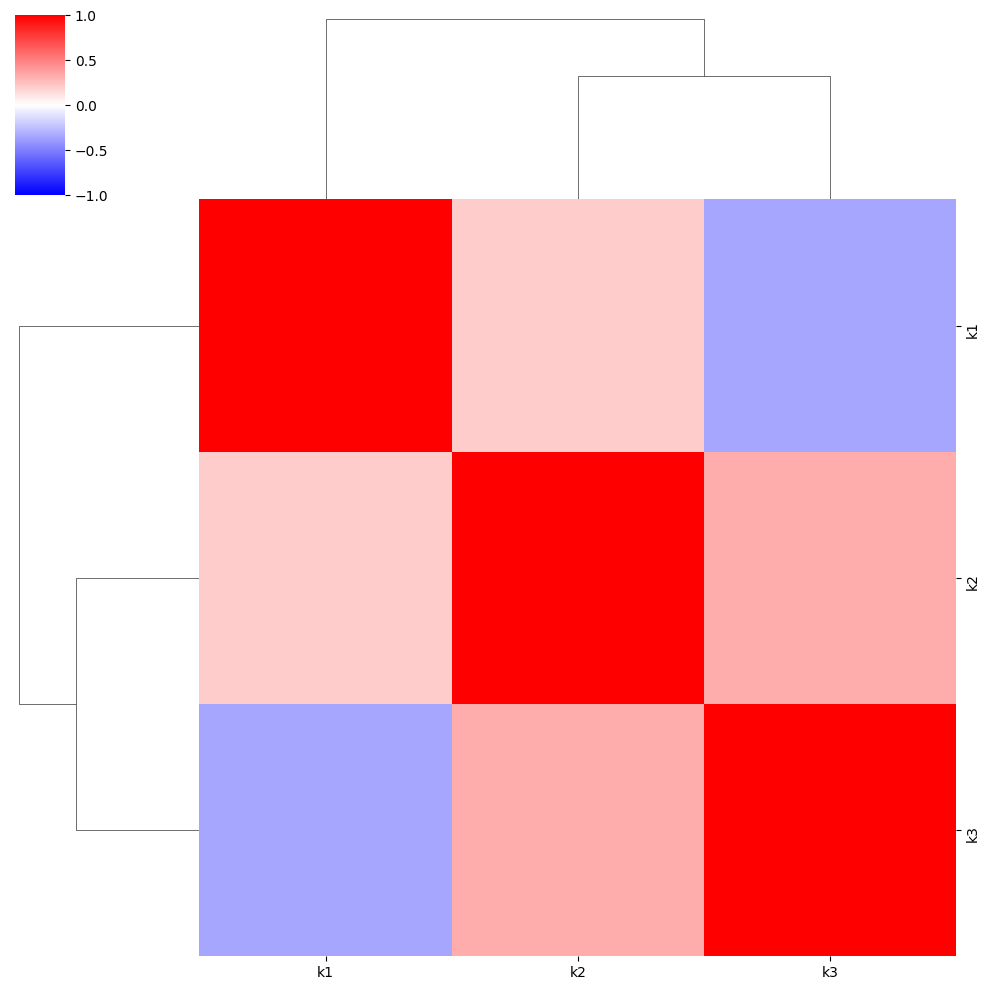

In [10]:
_ = visualize.parameters_correlation_matrix(result)